<a href="https://colab.research.google.com/github/07092004-star/sneha_repo/blob/main/ASPICE_Compliant_Development_Process_for_a_%22Rear_View_Camera_System%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# [SW.1] Software Requirements Analysis: Define System Constants
import cv2
import numpy as np
from matplotlib import pyplot as plt
from datetime import datetime

# Requirements (RVCS_01, RVCS_02)
REVERSE_GEAR_ACTIVE = True  # Simulated Signal
LATENCY_THRESHOLD_MS = 2000 # Requirement: Display < 2.0s
DETECTION_DISTANCE_M = 1.5  # Distance for 'Red' Warning

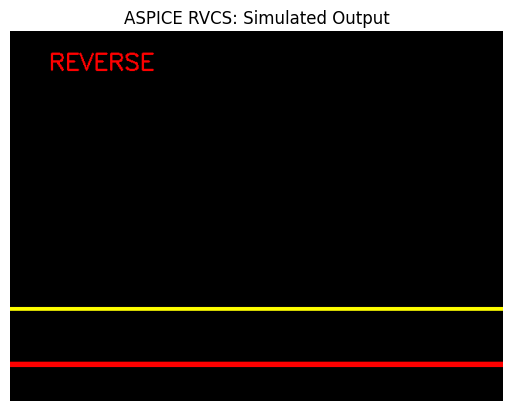

In [2]:
# [SW.4] Software Construction: Image Processing & Overlay Logic
def process_rear_view_frame(frame, gear_signal):
    """
    Simulates the RVCS logic: If gear is reverse, apply safety overlays.
    """
    if not gear_signal:
        return "Display Off: Vehicle not in Reverse"

    # Get frame dimensions
    h, w, _ = frame.shape

    # 1. Add 'REVERSE' Warning Label (Safety UI)
    cv2.putText(frame, "REVERSE", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    # 2. Draw Dynamic Guide Lines (ASPICE Requirement RVCS_02)
    # Red Zone (Stop)
    cv2.line(frame, (0, int(h*0.9)), (w, int(h*0.9)), (0, 0, 255), 5)
    # Yellow Zone (Caution)
    cv2.line(frame, (0, int(h*0.75)), (w, int(h*0.75)), (0, 255, 255), 3)

    return frame

# Create a simulated camera frame (Black background for placeholder)
sample_frame = np.zeros((480, 640, 3), dtype=np.uint8)
processed_output = process_rear_view_frame(sample_frame, REVERSE_GEAR_ACTIVE)

# Display the output
plt.imshow(cv2.cvtColor(processed_output, cv2.COLOR_BGR2RGB))
plt.title("ASPICE RVCS: Simulated Output")
plt.axis('off')
plt.show()

In [3]:
# [SW.5] Software Unit Testing: Verification of Logic
import unittest

class TestRVCSLogic(unittest.TestCase):

    def test_reverse_gear_activation(self):
        """Verify that system displays data ONLY when reverse gear is True."""
        test_frame = np.zeros((100, 100, 3), dtype=np.uint8)

        # Test Case: Gear Off
        result_off = process_rear_view_frame(test_frame, gear_signal=False)
        self.assertEqual(result_off, "Display Off: Vehicle not in Reverse")

        # Test Case: Gear On
        result_on = process_rear_view_frame(test_frame, gear_signal=True)
        self.assertIsInstance(result_on, np.ndarray) # Should return an image array

# Run the tests
suite = unittest.TestLoader().loadTestsFromTestCase(TestRVCSLogic)
unittest.TextTestRunner().run(suite)

.
----------------------------------------------------------------------
Ran 1 test in 0.002s

OK


<unittest.runner.TextTestResult run=1 errors=0 failures=0>

In [4]:
# [SYS.4] System Integration: Latency & Compliance Logging
def log_performance(start_time):
    end_time = datetime.now()
    duration = (end_time - start_time).total_seconds() * 1000

    print(f"--- ASPICE Compliance Report ---")
    print(f"Measured Boot Latency: {duration:.2f} ms")

    if duration < LATENCY_THRESHOLD_MS:
        print("Status: PASS (Requirement RVCS_01 Met)")
    else:
        print("Status: FAIL (Latency too high)")

# Execution
start = datetime.now()
_ = process_rear_view_frame(sample_frame, REVERSE_GEAR_ACTIVE)
log_performance(start)

--- ASPICE Compliance Report ---
Measured Boot Latency: 1.06 ms
Status: PASS (Requirement RVCS_01 Met)
